In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=UserWarning, append=True)

# Here, we are importing our previous DataFrames to keep the pipeline unbroken

In [2]:
df= pd.read_csv('preprocessed_sl_irrigation_water.csv')
print(f"Shape: {df.shape}  →  {df.shape[0]} records, {df.shape[1]} features")
pd.set_option('display.max_columns', None)
df.head()

Shape: (10000, 25)  →  10000 records, 25 features


,Field_Cycle_ID,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm
0,0,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70,0.0
1,0,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90,0.0
2,0,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05,0.0
3,0,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75,0.0
4,1,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05,2.8


In [3]:
X = df.drop(columns=['Net_Irrigation_Requirement_mm', 'Field_Cycle_ID'])
y = df['Net_Irrigation_Requirement_mm']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (10000, 23)
Target vector  y: (10000,)


In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=df['Field_Cycle_ID']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nTrain Target Mean: {y_train.mean():.2f}")
print(f"Test Target Mean : {y_test.mean():.2f}")

Training Set : 8000 records
Testing Set  : 2000 records

Train Target Mean: 22.48
Test Target Mean : 23.65


# Now, we are importing the DataFrame obtained after completing the EDA

In [5]:
X_train_clean= pd.read_csv('X_train_clean.csv')
print(f"Shape: {X_train_clean.shape}  →  {X_train_clean.shape[0]} records, {X_train_clean.shape[1]} features")
pd.set_option('display.max_columns', None)
X_train_clean.head()

Shape: (8000, 23)  →  8000 records, 23 features


,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc
0,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70
1,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90
2,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05
3,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75
4,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05


In [6]:
X_test_clean= pd.read_csv('X_test_clean.csv')
print(f"Shape: {X_test_clean.shape}  →  {X_test_clean.shape[0]} records, {X_test_clean.shape[1]} features")

Shape: (2000, 23)  →  2000 records, 23 features


In [7]:
y_train= pd.read_csv('y_train.csv')
y_train.shape

(8000, 1)

In [8]:
y_test=pd.read_csv('y_test.csv')
y_test.shape

(2000, 1)

# Convert our single-column DataFrame to a Series variable

In [9]:
y_train = y_train.squeeze()

In [10]:
y_test = y_test.squeeze()

In [11]:
quan=['Stage_Duration_days',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Organic_Carbon_pct',
 'Electrical_Conductivity_dSm',
 'Tmax_C',
 'Tmin_C',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc']

In [12]:
qual= ['Climate_Zone',
 'Season',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Soil_Type',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used']

# The Encoding (Categorical ----> Numarical)

In [13]:
from sklearn.preprocessing import OneHotEncoder

X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# here we find the categorical features as bianry and multiple class in X_train_encoded
#====================================================================================
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)})")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)})\n")
# ====================================================================================


# encoding our binary categorical features
# ====================================================================================
binary_maps = {}   

if binary_cols:
    for col in binary_cols:
        train_categories = sorted(X_train_encoded[col].astype(str).unique())
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        binary_maps[col] = binary_map   # ADD THIS — store it instead of letting it vanish
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
# ====================================================================================


# Here we are encoding the multi class categorical columns
# ====================================================================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)
# ====================================================================================

=== Encoding Feature Categorization ===
🔹 Binary features mapped (2)
🔹 Multi-class features mapped (6)



# Section: Building the Hurdle Model combining (classification + Regression)
### Classification model ----> Predicts whether irrigation is needed (0 or 1)
### Regression model ----> Predicts the exact volume of water required (in mm) if the irrigation needed

## 1. Classification Model

### Preparing the Dataset for the Classification Model

In [14]:
X_train

,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc
0,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70
1,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90
2,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05
3,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75
4,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,Wet,Maha,Chili,Late-season,30,Sandy,5.34,12.60,0.37,0.60,28.1,23.4,25.8,78.5,129.0,4.3,5.1,Drip,Major Tank,0.99,No,3.02,0.90
9996,Dry,Yala,Paddy (Rice),Initial,20,Sandy,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,Drip,Minor Tank,0.59,No,4.84,1.05
9997,Dry,Yala,Paddy (Rice),Development,30,Sandy,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,Drip,Minor Tank,0.59,No,5.27,1.10
9998,Dry,Yala,Paddy (Rice),Mid-season,40,Sandy,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,Drip,Minor Tank,0.59,No,5.37,1.20


In [15]:
X_train_encoded

,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,0,15,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,0.92,1,3.77,0.70,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
1,0,25,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,0.92,1,3.87,0.90,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2,0,35,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,0.92,1,2.79,1.05,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,20,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,0.92,1,3.09,0.75,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
4,0,20,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,1.63,0,4.43,1.05,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0,30,5.34,12.60,0.37,0.60,28.1,23.4,25.8,78.5,129.0,4.3,5.1,0.99,0,3.02,0.90,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0
7996,1,20,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,0.59,0,4.84,1.05,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
7997,1,30,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,0.59,0,5.27,1.10,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
7998,1,40,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,0.59,0,5.37,1.20,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0


In [16]:
X_train_clf= X_train_encoded.copy()
y_train_clf = (y_train > 0).astype(int)

In [17]:
X_test_clf= X_test_encoded.copy()
y_test_clf = (y_test > 0).astype(int)

In [18]:
X_train_clf

,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,0,15,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,0.92,1,3.77,0.70,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
1,0,25,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,0.92,1,3.87,0.90,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2,0,35,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,0.92,1,2.79,1.05,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,20,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,0.92,1,3.09,0.75,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
4,0,20,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,1.63,0,4.43,1.05,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0,30,5.34,12.60,0.37,0.60,28.1,23.4,25.8,78.5,129.0,4.3,5.1,0.99,0,3.02,0.90,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0
7996,1,20,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,0.59,0,4.84,1.05,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
7997,1,30,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,0.59,0,5.27,1.10,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
7998,1,40,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,0.59,0,5.37,1.20,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0


In [19]:
y_train_clf.unique()

array([0, 1])

# Features Scalling

In [20]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_clf_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clf), 
    columns=X_train_clf.columns, 
    index=X_train_clf.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_clf_scaled = pd.DataFrame(
    scaler.transform(X_test_clf), 
    columns=X_test_clf.columns, 
    index=X_test_clf.index
)

# Here we create a base line for the model using dummy classifier

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# 1. Initialize the baseline classifier (Always guesses the most frequent class label)
dummy_clf = DummyClassifier(strategy='most_frequent')

# 2. FIT: Train strictly on your scaled classification features and binary target
dummy_clf.fit(X_train_clf_scaled, y_train_clf)

# 3. PREDICT: Generate baseline guesses on your unseen test split
y_dummy_class_pred = dummy_clf.predict(X_test_clf_scaled)

# Since strategy='most_frequent' always outputs one class, we use predict_proba 
# with a small epsilon or uniform distribution to avoid undefined ROC AUC division errors
y_dummy_proba_pred = dummy_clf.predict_proba(X_test_clf_scaled)[:, 1]

# 4. Evaluate the baseline scores against your binary test target (y_test_clf)
baseline_auc = roc_auc_score(y_test_clf, y_dummy_proba_pred)
baseline_acc = accuracy_score(y_test_clf, y_dummy_class_pred)
baseline_f1  = f1_score(y_test_clf, y_dummy_class_pred, zero_division=0)

print("="*65)
print("📉 STAGE 1 BASELINE REPORT (DummyClassifier — Most Frequent Class)")
print("="*65)
print(f"Baseline CV/Test ROC AUC : {baseline_auc:.4f}")
print(f"Baseline Test Accuracy   : {baseline_acc * 100:.2f}%")
print(f"Baseline Test F1-Score   : {baseline_f1:.4f}")
print("="*65)
print(" CRITICAL PRODUCTION THRESHOLD:")
print("Your Random Forest Classifier MUST beat these metrics to have real business value.")
print("="*65)

📉 STAGE 1 BASELINE REPORT (DummyClassifier — Most Frequent Class)
Baseline CV/Test ROC AUC : 0.5000
Baseline Test Accuracy   : 56.70%
Baseline Test F1-Score   : 0.0000
 CRITICAL PRODUCTION THRESHOLD:
Your Random Forest Classifier MUST beat these metrics to have real business value.


# Checking the correlation between features to avoid the multicollinearity

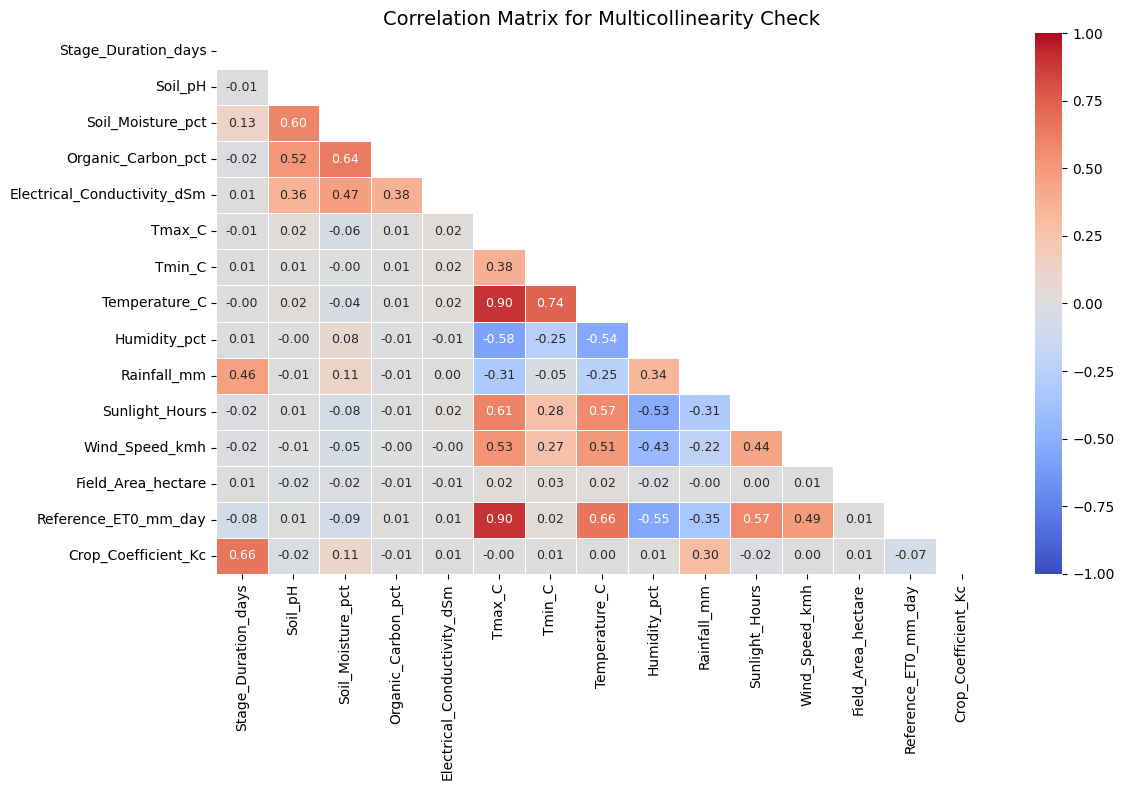


--- Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2258.005632
1                        Tmax_C  1206.380932
2                        Tmin_C   492.294251
3          Reference_ET0_mm_day    18.763033
4             Soil_Moisture_pct     2.338661
5           Stage_Duration_days     2.201410
6           Crop_Coefficient_Kc     1.822835
7                Sunlight_Hours     1.811430
8            Organic_Carbon_pct     1.809651
9                  Humidity_pct     1.771272
10                      Soil_pH     1.679424
11                  Rainfall_mm     1.575788
12               Wind_Speed_kmh     1.501685
13  Electrical_Conductivity_dSm     1.322529
14           Field_Area_hectare     1.002669


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure we ONLY check multicollinearity on numerical features
# (Using encoded categorical variables will break VIF or cause infinite scores)
X_train_numerical = X_train_clf_scaled[quan]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_numerical.columns

# Calculate VIF score safely for each numerical feature
vif_data["VIF"] = [
    variance_inflation_factor(X_train_numerical.values, i) 
    for i in range(X_train_numerical.shape[1])
]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

# Find the feature importence using RandomForestClassifier

--- Top 12 Most Important Features (Classification) ---
                 Feature  Importance
0            Rainfall_mm    0.356402
1                 Tmax_C    0.063100
2   Reference_ET0_mm_day    0.059231
3    Crop_Coefficient_Kc    0.055587
4           Humidity_pct    0.049080
5    Stage_Duration_days    0.042559
6          Temperature_C    0.040845
7         Sunlight_Hours    0.040102
8         Wind_Speed_kmh    0.027136
9       Climate_Zone_Wet    0.023281
10                Tmin_C    0.022426
11                Season    0.021546


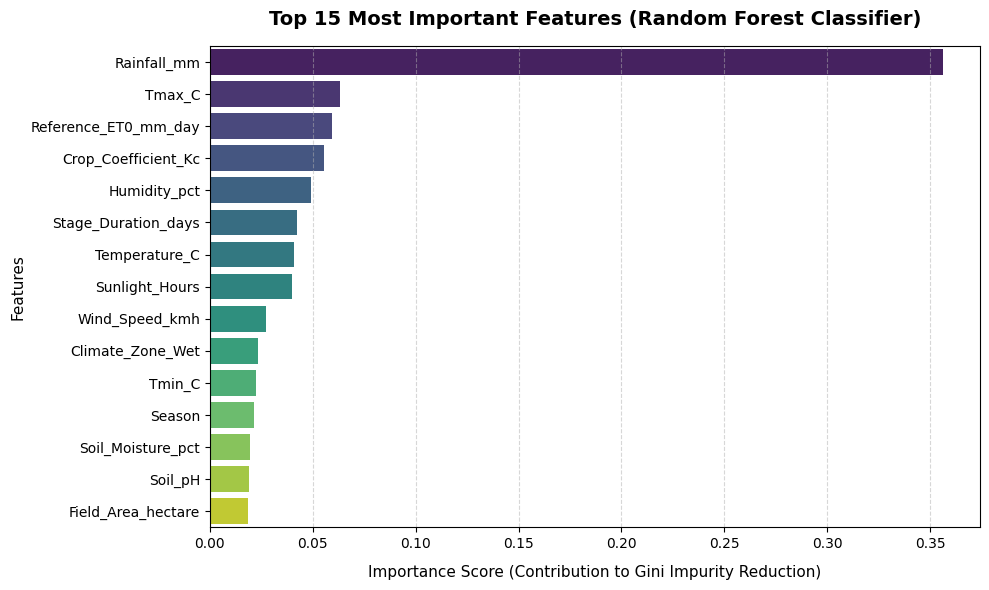

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# FIX 1: Import the Classifier instead of the Regressor
from sklearn.ensemble import RandomForestClassifier

# 1. INITIALIZE AND TRAIN THE MODEL FOR CLASSIFICATION
# FIX 2: Swap the model to Classifier and train on your binary target (y_train_clf)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_clf_scaled, y_train_clf)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_clf_scaled.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 12 Most Important Features (Classification) ---")
print(importance_df.head(12))

# =====================================================================
# 3. PLOT THE TOP 15 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select the top 15 rows to match your plotting variable
top_importance = importance_df.head(15)

# Set a wider, cleaner figure size optimized for 15 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using the top 15 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# FIX 3: Updated titles to reflect Classification (Gini Impurity Contribution)
plt.title('Top 15 Most Important Features (Random Forest Classifier)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Gini Impurity Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# We droped the featues (Tempreature_C and Tmax_C) to avoid Multicollinearity based on Correlation matrix, VIF Score and Featute Importance ranking

In [24]:
X_train_clf_final = X_train_clf_scaled.drop(columns=['Temperature_C', 'Tmin_C'])

# 2. Mirror the exact same step on the testing data
X_test_clf_final = X_test_clf_scaled.drop(columns=['Temperature_C', 'Tmin_C'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_clf_final.shape} | Test: {X_test_clf_final.shape}")

Cleaned Data Shapes -> Train: (8000, 41) | Test: (2000, 41)


# Finding the best features for prediction using RFECV

In [25]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold

# Extract the aligned group variable safely (pointing to your cleaned training index)
groups_aligned = df.loc[X_train_clf_final.index, 'Field_Cycle_ID']

# 1. Initialize a fast tree estimator for classification and group-based CV strategy
# FIX 2: Swap the model to ExtraTreesClassifier
fast_classifier = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
cv_strategy     = GroupKFold(n_splits=5) 

# 2. Fit RFECV using Classification Scoring (ROC AUC handles imbalanced zero days beautifully)
# FIX 3: Swap scoring from 'neg_mean_absolute_error' to 'roc_auc' (or 'accuracy')
rfecv_clf = RFECV(
    estimator=fast_classifier, 
    step=1, # Setting step=1 ensures precise dropping for feature optimization
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1
)

# FIX 4: Pass your classification features (X_train_clf_final) and binary target (y_train_clf)
rfecv_clf.fit(X_train_clf_final, y_train_clf, groups=groups_aligned)

# 3. Extract optimal indices
optimal_n_clf      = rfecv_clf.n_features_
selected_feats_clf = X_train_clf_final.columns[rfecv_clf.support_].tolist()

print("--- RFE Classification Selection Summary ---")
print(f"Original number of features : {X_train_clf_final.shape[1]}")
print(f"Number of selected features  : {optimal_n_clf}")

print("\n✅ SELECTED CLASSIFICATION FEATURES:")
print(selected_feats_clf)


--- RFE Classification Selection Summary ---
Original number of features : 41
Number of selected features  : 9

✅ SELECTED CLASSIFICATION FEATURES:
['Season', 'Stage_Duration_days', 'Tmax_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Climate_Zone_Wet']


# Here, we create a new dataframe that contains only the selected features

In [26]:
X_train_clf_pre = X_train_clf_final[selected_feats_clf]
X_test_clf_pre  = X_test_clf_final[selected_feats_clf]  

# Multi-Model Performance Benchmarking using only selected features

In [27]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# Extract aligned group IDs matching the exact index of your X_train_clf_pre matrix
train_groups = df.loc[X_train_clf_pre.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Binary Hurdle Decisions (0 = Dry, 1 = Water)
CLASSIFICATION_MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN Classifier":      KNeighborsClassifier(n_neighbors=5),
    "SVM Classifier (RBF)": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42, n_estimators=100),
}

# FIX 1: Generate the binary target for testing (Implicit deep copy, completely leak-free)
y_test_clf = (y_test > 0).astype(int)

results_clf = []
for name, model in CLASSIFICATION_MODELS.items():
    
    # 3. Step A: Cross-Validation using ROC AUC
    cv_scores = cross_val_score(
        model, 
        X_train_clf_pre, 
        y_train_clf, 
        cv=cv5, 
        groups=train_groups, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    mean_cv_auc = cv_scores.mean()
    
    # 4. Step B: Train ONCE on the training matrix to predict on the test set
    model.fit(X_train_clf_pre, y_train_clf)
    
    # Predict hard classes (0 or 1) and continuous probabilities
    y_pred_class = model.predict(X_test_clf_pre)
    y_pred_proba = model.predict_proba(X_test_clf_pre)[:, 1]
    
    # 5. FIX 2: Calculate classification performance metrics against y_test_clf (NOT y_test)
    test_auc      = roc_auc_score(y_test_clf, y_pred_proba)
    test_accuracy = accuracy_score(y_test_clf, y_pred_class)
    test_f1       = f1_score(y_test_clf, y_pred_class)
    
    # 6. Collect all classification metrics for this model row
    results_clf.append({
        "Model": name,
        "CV ROC AUC (Train)": mean_cv_auc, 
        "Test ROC AUC":       test_auc,
        "Test Accuracy":      test_accuracy,
        "Test F1-Score":      test_f1
    })

# 7. Turn into a DataFrame and rank by the HIGHEST Cross-Validation ROC AUC score
benchmark_table_clf = pd.DataFrame(results_clf)
benchmark_table_clf = benchmark_table_clf.sort_values(by="Test F1-Score", ascending=False).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_clf["CV ROC AUC (Train)"] = benchmark_table_clf["CV ROC AUC (Train)"].map(lambda x: f"{x:.4f}")
benchmark_table_clf["Test ROC AUC"]       = benchmark_table_clf["Test ROC AUC"].map(lambda x: f"{x:.4f}")
benchmark_table_clf["Test Accuracy"]      = benchmark_table_clf["Test Accuracy"].map(lambda x: f"{x*100:.2f}%" if not pd.isna(x) else x)
benchmark_table_clf["Test F1-Score"]      = benchmark_table_clf["Test F1-Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 1 CLASSIFICATION MODEL BENCHMARK TABLE (Ranked by Highest CV ROC AUC)")
print("="*95)
display(benchmark_table_clf)


📊 STAGE 1 CLASSIFICATION MODEL BENCHMARK TABLE (Ranked by Highest CV ROC AUC)


,Model,CV ROC AUC (Train),Test ROC AUC,Test Accuracy,Test F1-Score
0,Random Forest,0.9930,0.9946,96.00%,0.9533
1,SVM Classifier (RBF),0.9940,0.9940,95.95%,0.9531
2,Gradient Boosting,0.9946,0.9954,95.85%,0.9515
3,Decision Tree,0.9407,0.9490,94.90%,0.9416
4,Logistic Regression,0.9897,0.9893,94.00%,0.9310
5,KNN Classifier,0.9640,0.9724,91.85%,0.9035


### The Random Forest Classifier was selected because it achieved the top Test Accuracy (96.00%) and Test F1-Score (0.9533), generalized perfectly to unseen fields without overfitting

# Here we are finding the best parameters for our model

In [28]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import RandomForestClassifier

groups_clf = df.loc[X_train_clf_pre.index, 'Field_Cycle_ID']

param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}
cv = GroupKFold(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=30,          # Only evaluates 30 combinations
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

random_search.fit(
    X_train_clf_pre,
    y_train_clf,
    groups=groups_clf
)

best_rf_classifier = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
0.9931810555064466


# Classification Performance Evaluation

🏆 FINAL TUNED STAGE 1 CLASSIFICATION MODEL REPORT
Final Model ROC AUC Score           : 0.9946
                  precision    recall  f1-score   support

     Dry Day (0)       0.96      0.97      0.96      1134
Watering Day (1)       0.96      0.94      0.95       866

        accuracy                           0.96      2000
       macro avg       0.96      0.96      0.96      2000
    weighted avg       0.96      0.96      0.96      2000



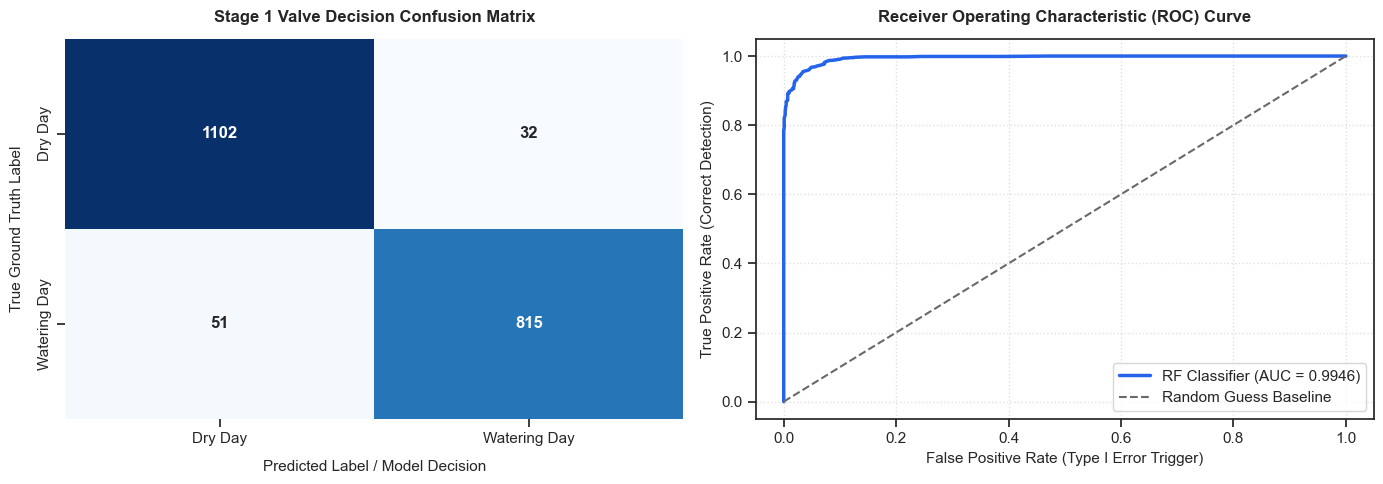

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Import Proper Classification Reporting Modules
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    ConfusionMatrixDisplay
)

# 1. Predict on your SELECTED classification test features
y_pred_class = best_rf_classifier.predict(X_test_clf_pre)
y_pred_proba = best_rf_classifier.predict_proba(X_test_clf_pre)[:, 1]

# 2. Calculate Final Performance Metrics on Unseen Classification Test Data
final_auc = roc_auc_score(y_test_clf, y_pred_proba)

print("🏆 FINAL TUNED STAGE 1 CLASSIFICATION MODEL REPORT")
print("=" * 65)
print(f"Final Model ROC AUC Score           : {final_auc:.4f}")
print("=" * 65)
# Generates complete Precision, Recall, and F1 breakdowns for both class 0 and class 1
print(classification_report(y_test_clf, y_pred_class, target_names=['Dry Day (0)', 'Watering Day (1)']))
print("=" * 65)

# 3. Structural Evaluation Graphics Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="ticks")

# Plot A: Confusion Matrix Heatmap (Reveals Valve Control Misclassifications)
cm = confusion_matrix(y_test_clf, y_pred_class)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0], 
    xticklabels=['Dry Day', 'Watering Day'], 
    yticklabels=['Dry Day', 'Watering Day'],
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_xlabel('Predicted Label / Model Decision', fontsize=11, labelpad=10)
axes[0].set_ylabel('True Ground Truth Label', fontsize=11, labelpad=10)
axes[0].set_title('Stage 1 Valve Decision Confusion Matrix', fontsize=12, fontweight='bold', pad=12)

# Plot B: ROC Curve (Evaluates General Classifier Separation Thresholds)
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2563EB', linewidth=2.5, label=f'RF Classifier (AUC = {final_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='dimgray', linestyle='--', linewidth=1.5, label='Random Guess Baseline')
axes[1].set_xlabel('False Positive Rate (Type I Error Trigger)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Correct Detection)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [60]:
import joblib

# Save the classification model directly in the current directory
joblib.dump(best_rf_classifier, 'stage1_classifier.joblib')
print("✅ Stage 1 Classifier saved successfully!")

✅ Stage 1 Classifier saved successfully!


# 2. Regression Model for Predicting Irrigation Water Volume

### Preparing the Dataset for the Regression Model

In [30]:
# 1. Define the mask strictly based on active watering days (Ground truth > 0)
mask = y_train > 0

# 2. Filter your SELECTED training features and target matrices cleanly
# FIX: Using your clean, selected feature space instead of raw X_train
X_train_reg = X_train_encoded[mask].copy() 
y_train_reg = y_train[mask].copy()

# 3. Mirror the exact same step on the testing data to keep dimensions aligned
mask_test = y_test > 0
X_test_reg  = X_test_encoded[mask_test].copy()
y_test_reg  = y_test[mask_test].copy()

# --- Quick verification check ---
print("="*60)
print("🔒 STAGE 2 DATA ISOLATION COMPLETE (Active Watering Days Only)")
print("="*60)
print(f"Regression Training Matrix Shape : {X_train_reg.shape}")
print(f"Regression Testing Matrix Shape  : {X_test_reg.shape}")
print("="*60)

🔒 STAGE 2 DATA ISOLATION COMPLETE (Active Watering Days Only)
Regression Training Matrix Shape : (3432, 43)
Regression Testing Matrix Shape  : (866, 43)


# Scalling the features

In [31]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Initialize a fresh StandardScaler instance exclusively for Stage 2 Regression
reg_scaler = StandardScaler()

# 2. FIT & TRANSFORM: Calculate mean/variance ONLY on active watering training rows
X_train_reg_scaled = pd.DataFrame(
    reg_scaler.fit_transform(X_train_reg), 
    columns=X_train_reg.columns, 
    index=X_train_reg.index
)

# 3. TRANSFORM ONLY: Mirror onto the regression test set (No Leakage)
X_test_reg_scaled = pd.DataFrame(
    reg_scaler.transform(X_test_reg), 
    columns=X_test_reg.columns, 
    index=X_test_reg.index
)

# --- Quick verification check ---
print("="*60)
print(f"Scaled Reg Train Dimensions : {X_train_reg_scaled.shape}")
print(f"Scaled Reg Test Dimensions  : {X_test_reg_scaled.shape}")
print("="*60)


Scaled Reg Train Dimensions : (3432, 43)
Scaled Reg Test Dimensions  : (866, 43)


# Dummy regressor for the baseline

In [32]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the baseline regressor (always predicts the mean of active watering days)
dummy_reg = DummyRegressor(strategy='mean')

# FIX: Fit strictly on the positive-only training rows
dummy_reg.fit(X_train_reg_scaled, y_train_reg)

# 2. Predict on the isolated regression test set
y_dummy_pred = dummy_reg.predict(X_test_reg_scaled)

# 3. Evaluate the benchmark against the positive test ground-truth (y_test_reg)
print("="*65)
print(f"Baseline MAE      : {mean_absolute_error(y_test_reg, y_dummy_pred):.2f} mm")
print(f"Baseline R² Score : {r2_score(y_test_reg, y_dummy_pred):.4f}")
print("="*65)
print("Any Stage 2 model you train MUST achieve a LOWER MAE and a HIGHER R² score than this.")
print("="*65)

Baseline MAE      : 36.58 mm
Baseline R² Score : -0.0022
Any Stage 2 model you train MUST achieve a LOWER MAE and a HIGHER R² score than this.


# Checking the correlation between features to avoid the multicollinearity

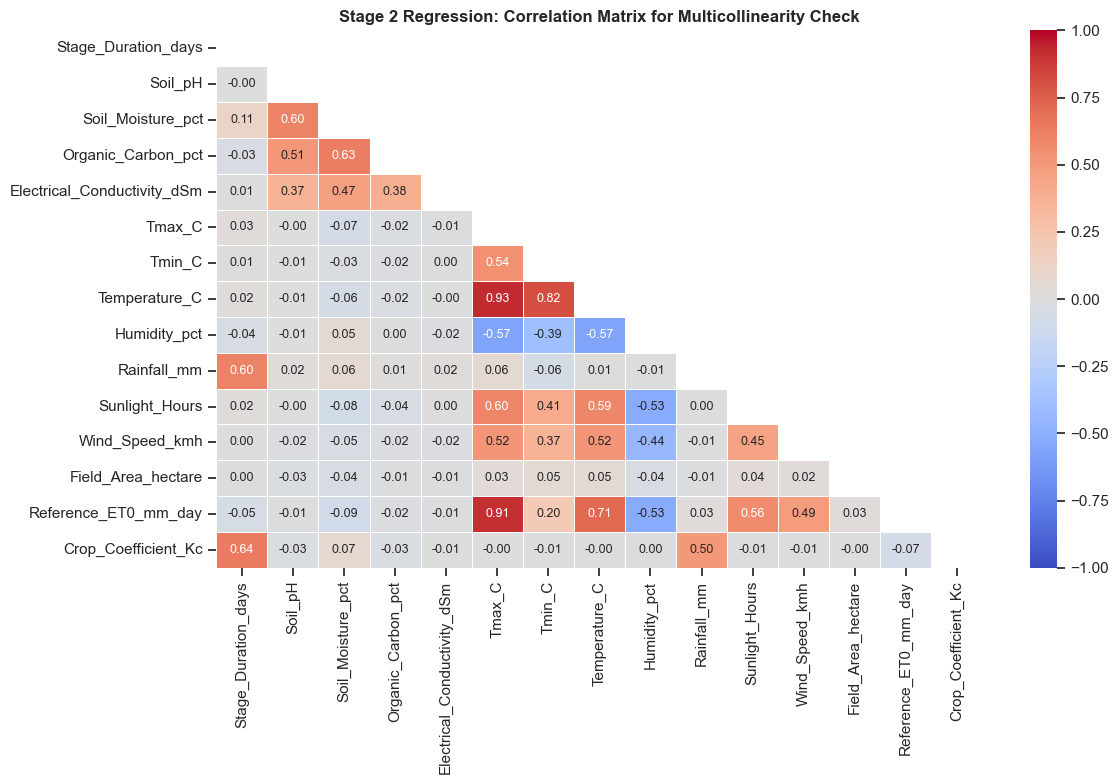


--- Stage 2 Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2459.231312
1                        Tmax_C  1179.428938
2                        Tmin_C   491.854017
3          Reference_ET0_mm_day    21.683738
4             Soil_Moisture_pct     2.278103
5           Stage_Duration_days     2.192430
6                Sunlight_Hours     1.856089
7            Organic_Carbon_pct     1.779597
8           Crop_Coefficient_Kc     1.774960
9                  Humidity_pct     1.721280
10                      Soil_pH     1.681691
11                  Rainfall_mm     1.681279
12               Wind_Speed_kmh     1.523162
13  Electrical_Conductivity_dSm     1.319651
14           Field_Area_hectare     1.006179


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. FIX: Intersect your quantitative feature list with active Stage 2 columns
# This protects against KeyError if features were dropped or altered upstream
quan_existing = [col for col in quan if col in X_train_reg_scaled.columns]
X_train_numerical_reg = X_train_reg_scaled[quan_existing]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical_reg.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Stage 2 Regression: Correlation Matrix for Multicollinearity Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data_reg = pd.DataFrame()
vif_data_reg["Feature"] = X_train_numerical_reg.columns

# Calculate VIF score safely for each active numerical feature in the regression space
vif_data_reg["VIF"] = [
    variance_inflation_factor(X_train_numerical_reg.values, i) 
    for i in range(X_train_numerical_reg.shape[1])
]

# Sort features by VIF score in descending order
vif_data_reg = vif_data_reg.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Stage 2 Variance Inflation Factor (VIF) Scores ---")
print(vif_data_reg)

# Here we are finding the feature importance

--- Top 12 Most Important Features (Stage 2 Regression) ---
                 Feature  Importance
0    Stage_Duration_days    0.332606
1            Rainfall_mm    0.258236
2   Reference_ET0_mm_day    0.181388
3    Crop_Coefficient_Kc    0.104526
4                 Tmax_C    0.018157
5          Temperature_C    0.014154
6      Soil_Moisture_pct    0.012806
7           Humidity_pct    0.007972
8         Sunlight_Hours    0.006369
9         Wind_Speed_kmh    0.006138
10    Organic_Carbon_pct    0.006057
11               Soil_pH    0.005305


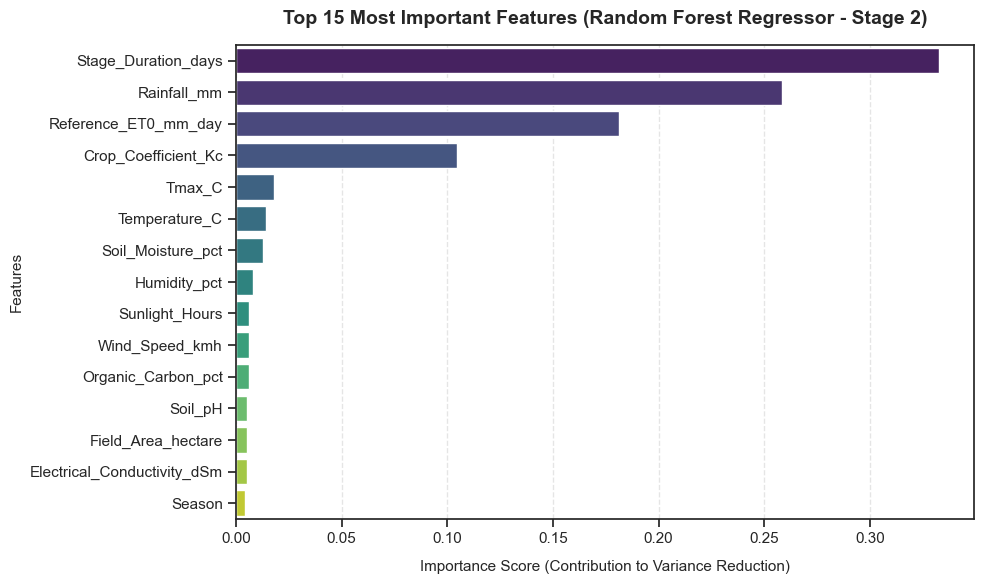

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. INITIALIZE AND TRAIN THE MODEL ON STAGE 2 REGRESSION DATA
# FIX: Swapped inputs to your positive-only, scaled regression variables
rf_regressor_stage2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor_stage2.fit(X_train_reg_scaled, y_train_reg)

# 2. EXTRACT SCORES AND PAIR THEM WITH REGRESSION COLUMN NAMES
# FIX: Updated column references to match X_train_reg_scaled columns
importance_df_reg = pd.DataFrame({
    'Feature': X_train_reg_scaled.columns,
    'Importance': rf_regressor_stage2.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 12 Most Important Features (Stage 2 Regression) ---")
print(importance_df_reg.head(12))

# =====================================================================
# 3. PLOT THE TOP 15 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select the top 15 rows to match your slice index down below
top_importance_reg = importance_df_reg.head(15)

# Set a wider, cleaner figure size optimized for 15 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using only the top 15 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance_reg, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# Add clean labels, a larger title, and clear gridlines for readability
plt.title('Top 15 Most Important Features (Random Forest Regressor - Stage 2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Variance Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# We droped the featues (Tempreature_C and Tmax_C) to avoid Multicollinearity based on Correlation matrix, VIF Score and Featute Importance ranking

In [35]:
X_train_reg_final = X_train_reg_scaled.drop(columns=['Temperature_C', 'Tmin_C'], errors='ignore')
X_test_reg_final  = X_test_reg_scaled.drop(columns=['Temperature_C', 'Tmin_C'], errors='ignore')

# Finding the best features using RFECV using GroupKFold

In [36]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold

# Extract the aligned group variable safely from the isolated regression index
# FIX 1: Point to your Stage 2 regression feature matrix index
groups_aligned_reg = df.loc[X_train_reg_final.index, 'Field_Cycle_ID']

# 1. Initialize a fast tree estimator and group-based CV strategy
fast_estimator_reg = ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1)
cv_strategy_reg    = GroupKFold(n_splits=5) 

# 2. Fit RFECV using Negative MAE Scoring
rfecv_reg = RFECV(
    estimator=fast_estimator_reg, 
    step=1, # Setting step=1 ensures highly precise feature pruning
    cv=cv_strategy_reg, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1
)

# Fit using the safely aligned groups array
# FIX 2: Pass your exact Stage 2 matrices (X_train_reg_final and y_train_reg)
rfecv_reg.fit(X_train_reg_final, y_train_reg, groups=groups_aligned_reg)

# 3. Extract optimal indices
optimal_n_reg      = rfecv_reg.n_features_
selected_feats_reg = X_train_reg_final.columns[rfecv_reg.support_].tolist()

print("--- RFE Stage 2 Regression Selection Summary ---")
print(f"Original number of features : {X_train_reg_final.shape[1]}")
print(f"Number of selected features  : {optimal_n_reg}")

print("\n✅ SELECTED REGRESSION FEATURES:")
print(selected_feats_reg)

--- RFE Stage 2 Regression Selection Summary ---
Original number of features : 41
Number of selected features  : 14

✅ SELECTED REGRESSION FEATURES:
['Season', 'Stage_Duration_days', 'Soil_Moisture_pct', 'Tmax_C', 'Rainfall_mm', 'Sunlight_Hours', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Climate_Zone_Dry', 'Climate_Zone_Wet', 'Crop_Type_Chili', 'Crop_Type_Green Gram', 'Crop_Type_Paddy (Rice)', 'Crop_Growth_Stage_Mid-season']


# Here, we create a new dataframe that contains only the selected features

In [37]:
# Isolate the optimal feature subsets selected by RFECV for Stage 2 Regression
X_train_reg_pre = X_train_reg_final[selected_feats_reg]
X_test_reg_pre  = X_test_reg_final[selected_feats_reg]

print()
print(f"Final Regression Training Features Size : {X_train_reg_pre.shape}")
print(f"Final Regression Testing Features Size  : {X_test_reg_pre.shape}")



Final Regression Training Features Size : (3432, 14)
Final Regression Testing Features Size  : (866, 14)


# Multi-Model Performance Benchmarking using only selected features

In [38]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# FIX 1: Extract aligned group IDs matching the exact index of your X_train_reg_pre matrix
train_groups_reg = df.loc[X_train_reg_pre.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions (Watering Days Only)
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results_reg = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE with Group Constraints
    # FIX 2: Pass Stage 2 variables (X_train_reg_pre, y_train_reg)
    cv_scores = cross_val_score(
        model, 
        X_train_reg_pre, 
        y_train_reg, 
        cv=cv5, 
        groups=train_groups_reg, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on the positive-only training matrix to predict on the test set
    # FIX 3: Pass Stage 2 variables (X_train_reg_pre, y_train_reg)
    model.fit(X_train_reg_pre, y_train_reg)
    y_pred = model.predict(X_test_reg_pre)
    
    # 5. Calculate exact performance metrics against positive test ground truth (y_test_reg)
    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    
    # 6. Collect all metrics for this model row
    results_reg.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
benchmark_table_reg = pd.DataFrame(results_reg)
benchmark_table_reg = benchmark_table_reg.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_reg["CV MAE (Train)"] = benchmark_table_reg["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test MAE (mm)"]  = benchmark_table_reg["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test RMSE (mm)"] = benchmark_table_reg["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test R² Score"]  = benchmark_table_reg["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 2 REGRESSION MODEL BENCHMARK TABLE (Active Watering Days Only)")
print("="*95)
display(benchmark_table_reg)


📊 STAGE 2 REGRESSION MODEL BENCHMARK TABLE (Active Watering Days Only)


,Model,CV MAE (Train),Test MAE (mm),Test RMSE (mm),Test R² Score
0,Gradient Boosting,9.29 mm,9.28 mm,12.81 mm,0.9275
1,Random Forest,9.54 mm,9.10 mm,13.08 mm,0.9245
2,Ridge Regression,12.99 mm,13.56 mm,17.59 mm,0.8633
3,Linear Regression,12.99 mm,13.56 mm,17.59 mm,0.8633
4,Decision Tree,13.49 mm,12.87 mm,19.84 mm,0.8262
5,KNN Regressor,13.95 mm,12.66 mm,16.77 mm,0.8758
6,SVM Regressor (RBF),15.61 mm,14.70 mm,22.70 mm,0.7724


# Here, we analyze the best features and rank them based on feature importance to pick only a few, making the model easy to use and  cost-effective

In [39]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train the proper continuous regression engine
# FIX: Swapped inputs to your positive-only, pre-selected regression variables
reg_production_engine = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_production_engine.fit(X_train_reg_pre, y_train_reg)

# 2. Extract and match scores using your optimized regression feature columns
# FIX: Updated index reference to match X_train_reg_pre columns
rankings_reg = pd.Series(reg_production_engine.feature_importances_, index=X_train_reg_pre.columns)
limited_features_reg = rankings_reg.nlargest(5).index.tolist()

print("--- True Random Forest Regressor Rankings (Stage 2) ---")
print(rankings_reg.sort_values(ascending=False))

print(f"\n✅ Use these 5 features for your cost-effective Stage 2 deployment pipeline:\n{limited_features_reg}")

--- True Random Forest Regressor Rankings (Stage 2) ---
Stage_Duration_days             0.338261
Rainfall_mm                     0.269679
Reference_ET0_mm_day            0.196941
Crop_Coefficient_Kc             0.109876
Tmax_C                          0.029215
Soil_Moisture_pct               0.023348
Sunlight_Hours                  0.013487
Season                          0.005635
Crop_Type_Chili                 0.005469
Crop_Growth_Stage_Mid-season    0.003881
Crop_Type_Paddy (Rice)          0.001906
Climate_Zone_Wet                0.001015
Climate_Zone_Dry                0.000988
Crop_Type_Green Gram            0.000299
dtype: float64

✅ Use these 5 features for your cost-effective Stage 2 deployment pipeline:
['Stage_Duration_days', 'Rainfall_mm', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Tmax_C']


In [40]:
limited_features_reg

['Stage_Duration_days',
 'Rainfall_mm',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Tmax_C']

# Here, we create a new dataframe that contains only the limited selected features

In [41]:
# The elite, dynamic pandas execution way for Stage 2
X_train_reg_selected = X_train_reg_final[limited_features_reg]
X_test_reg_selected  = X_test_reg_final[limited_features_reg]

print(f"\nFinal Ready Regression Shapes ➔ Train: {X_train_reg_selected.shape} | Test: {X_test_reg_selected.shape}\n")


Final Ready Regression Shapes ➔ Train: (3432, 5) | Test: (866, 5)



In [42]:
print("--- Features Matrix Columns Verification ---")
print(list(X_train_reg_selected.columns))
print()

--- Features Matrix Columns Verification ---
['Stage_Duration_days', 'Rainfall_mm', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Tmax_C']



# Multi-Model Performance Benchmarking using only limited features

In [43]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# FIX 1: Extract aligned group IDs matching the exact index of your SELECTED 5-feature training matrix
train_groups_reg = df.loc[X_train_reg_selected.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions (Top 5 Features Only)
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results_reg_limited = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE with Group Constraints
    # FIX 2: Pass your top-5 Stage 2 variables (X_train_reg_selected, y_train_reg)
    cv_scores = cross_val_score(
        model, 
        X_train_reg_selected, 
        y_train_reg, 
        cv=cv5, 
        groups=train_groups_reg, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on full 5-feature training data to predict on the 5-feature test set
    # FIX 3: Pass your top-5 Stage 2 variables (X_train_reg_selected, y_train_reg)
    model.fit(X_train_reg_selected, y_train_reg)
    y_pred = model.predict(X_test_reg_selected)
    
    # 5. Calculate exact performance metrics against positive test ground truth (y_test_reg)
    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    
    # 6. Collect all metrics for this model row
    results_reg_limited.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
benchmark_table_limited_reg = pd.DataFrame(results_reg_limited)
benchmark_table_limited_reg = benchmark_table_limited_reg.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_limited_reg["CV MAE (Train)"] = benchmark_table_limited_reg["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test MAE (mm)"]  = benchmark_table_limited_reg["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test RMSE (mm)"] = benchmark_table_limited_reg["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test R² Score"]  = benchmark_table_limited_reg["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 2 REGRESSION BENCHMARK TABLE (Top 5 Pruned Features Only)")
print("="*95)
display(benchmark_table_limited_reg)


📊 STAGE 2 REGRESSION BENCHMARK TABLE (Top 5 Pruned Features Only)


,Model,CV MAE (Train),Test MAE (mm),Test RMSE (mm),Test R² Score
0,Gradient Boosting,9.98 mm,9.91 mm,13.82 mm,0.9157
1,Random Forest,10.10 mm,9.58 mm,13.58 mm,0.9185
2,KNN Regressor,10.61 mm,9.96 mm,13.89 mm,0.9148
3,Decision Tree,13.02 mm,12.68 mm,17.68 mm,0.8619
4,SVM Regressor (RBF),13.08 mm,13.13 mm,20.83 mm,0.8084
5,Ridge Regression,14.26 mm,14.80 mm,19.15 mm,0.8380
6,Linear Regression,14.26 mm,14.80 mm,19.15 mm,0.8380


# Here, we are comparing the benchmark results between all selected features (17 features) and the limited feature set (5 features)

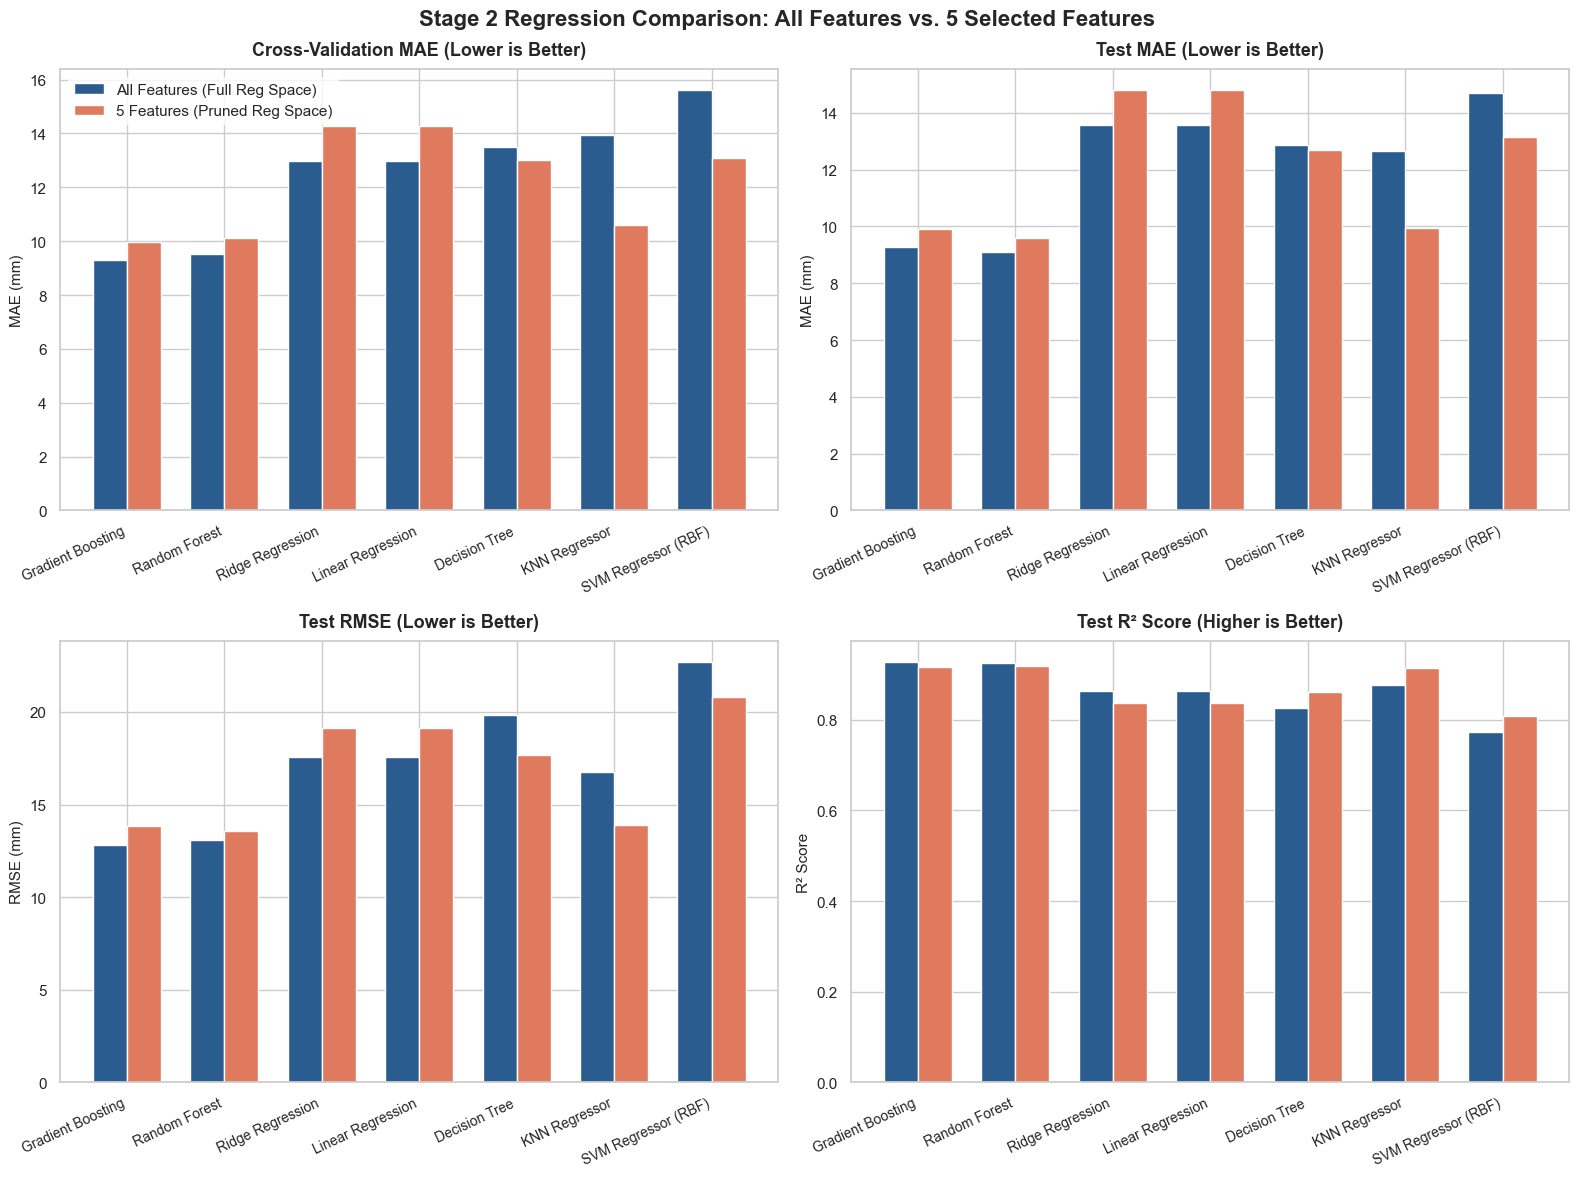

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Prepare numerical data for plotting using your correct Stage 2 variable name
# FIX 1: Point to your Stage 2 full features benchmark table
models = benchmark_table_reg["Model"].values
x = np.arange(len(models))
width = 0.35

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)
axes = axes.flatten()

# Metrics to loop through along with their clean labels and column sources
metrics_config = [
    {"title": "Cross-Validation MAE (Lower is Better)", "ylabel": "MAE (mm)", "sel_col": "CV MAE (Train)", "lim_col": "CV MAE (Train)", "unit": " mm"},
    {"title": "Test MAE (Lower is Better)", "ylabel": "MAE (mm)", "sel_col": "Test MAE (mm)", "lim_col": "Test MAE (mm)", "unit": " mm"},
    {"title": "Test RMSE (Lower is Better)", "ylabel": "RMSE (mm)", "sel_col": "Test RMSE (mm)", "lim_col": "Test RMSE (mm)", "unit": " mm"},
    {"title": "Test R² Score (Higher is Better)", "ylabel": "R² Score", "sel_col": "Test R² Score", "lim_col": "Test R² Score", "unit": None}
]

# 2. Generate the 4 subplots dynamically
for i, config in enumerate(metrics_config):
    ax = axes[i]
    
    # Extract numerical arrays from both tables safely matching the exact model order
    # FIX 2: Point directly to your active Stage 2 regression results tables
    df_sel_idx = benchmark_table_reg.set_index("Model")
    df_lim_idx = benchmark_table_limited_reg.set_index("Model")
    
    if config["unit"]:
        vals_all = df_sel_idx.loc[models, config["sel_col"]].str.replace(config["unit"], "", regex=False).astype(float).values
        vals_5ft = df_lim_idx.loc[models, config["lim_col"]].str.replace(config["unit"], "", regex=False).astype(float).values
    else:
        vals_all = df_sel_idx.loc[models, config["sel_col"]].astype(float).values
        vals_5ft = df_lim_idx.loc[models, config["lim_col"]].astype(float).values

    # Plot bars side-by-side
    rects1 = ax.bar(x - width/2, vals_all, width, label='All Features (Full Reg Space)', color='#2b5c8f')
    rects2 = ax.bar(x + width/2, vals_5ft, width, label='5 Features (Pruned Reg Space)', color='#e07a5f')
    
    # Subplot details
    ax.set_title(config["title"], fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(config["ylabel"], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    
    # Add legend only to the first plot to avoid cluttering the visual space
    if i == 0:
        ax.legend(frameon=True, facecolor='white', edgecolor='none')

# Adjust layout to make room for titles and rotated text labels
plt.suptitle("Stage 2 Regression Comparison: All Features vs. 5 Selected Features", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Based on the graph, we selected the 5-feature set to train the final model because:
## 1. There is no significant difference in performance between using 14 features and 5 features.
## 2. Utilizing fewer features is computationally cost-effective and creates a simpler, more user-friendly interface."

# Hyperparameter Tuning: Optimizing the Gradient Boosting Model

In [45]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import GradientBoostingRegressor

param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1]
}

cv_strategy_reg = GroupKFold(n_splits=5)

grid_search_reg = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_reg,
    cv=cv_strategy_reg,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    refit=True,
    verbose=1
)

groups_reg = df.loc[X_train_reg_selected.index, 'Field_Cycle_ID']
grid_search_reg.fit(X_train_reg_selected, y_train_reg, groups=groups_reg)

best_gb_model_reg = grid_search_reg.best_estimator_   # keep the variable name — everything downstream references it

print("\n--- 🎯 Stage 2 Regression Hyperparameter Tuning Summary ---")
print(f"Best GB Parameters : {grid_search_reg.best_params_}")
print(f"Best CV MAE        : {-grid_search_reg.best_score_:.2f} mm")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- 🎯 Stage 2 Regression Hyperparameter Tuning Summary ---
Best GB Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best CV MAE        : 9.52 mm


# Final Model Evaluation & Diagnostic Plots

🏆 FINAL TUNED STAGE 2 REGRESSION MODEL REPORT (Active Watering Only)
Final Mean Absolute Error (MAE) : 9.35 mm
Final Root Mean Squared Error   : 13.29 mm
Final R² Score (Variance Match) : 0.9220


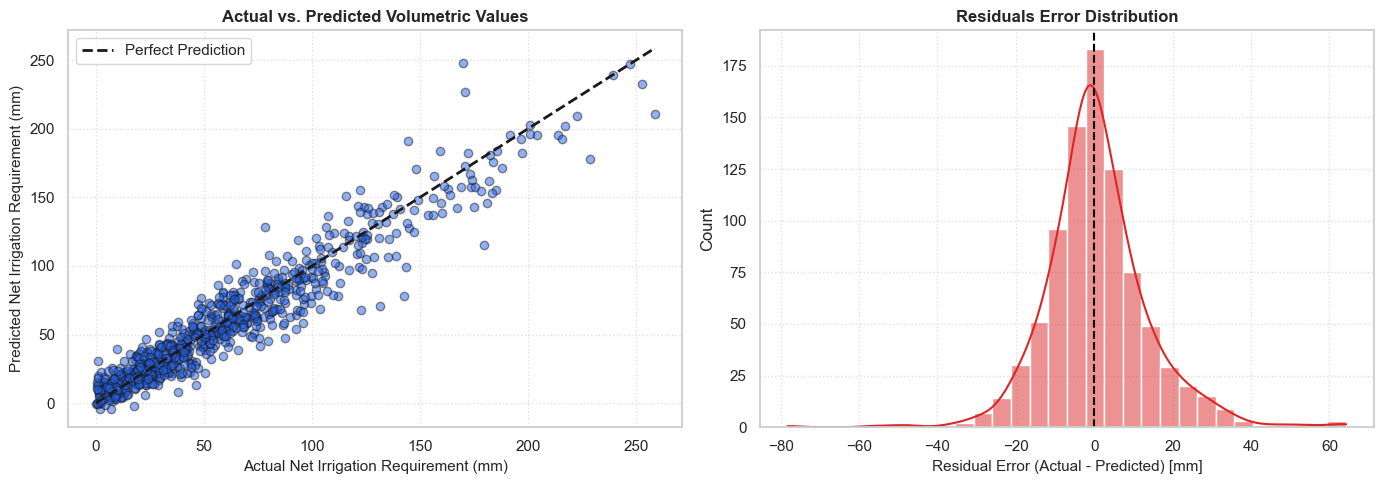

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. UPDATED: Predict on your SELECTED test features using your tuned Stage 2 Gradient Boosting engine
y_pred_reg = best_gb_model_reg.predict(X_test_reg_selected)

# 2. Calculate Final Performance Metrics against positive test data (y_test_reg)
final_mae_reg  = mean_absolute_error(y_test_reg, y_pred_reg)
final_rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
final_r2_reg   = r2_score(y_test_reg, y_pred_reg)

print("🏆 FINAL TUNED STAGE 2 REGRESSION MODEL REPORT (Active Watering Only)")
print("=" * 65)
print(f"Final Mean Absolute Error (MAE) : {final_mae_reg:.2f} mm")
print(f"Final Root Mean Squared Error   : {final_rmse_reg:.2f} mm")
print(f"Final R² Score (Variance Match) : {final_r2_reg:.4f}")
print("=" * 65)

# 3. Structural Evaluation Graphics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="ticks")

# Plot A: Prediction vs Actuals (Ideally a tight diagonal 45-degree line)
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#2563EB', edgecolors='k')
ideal_line = [min(y_test_reg), max(y_test_reg)]
axes[0].plot(ideal_line, ideal_line, 'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_ylabel('Predicted Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_title('Actual vs. Predicted Volumetric Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot B: Residuals Distribution (Checks if errors are normally distributed around 0)
residuals_reg = y_test_reg - y_pred_reg
sns.histplot(residuals_reg, kde=True, color='#DC2626', ax=axes[1], bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Error (Actual - Predicted) [mm]', fontsize=11)
axes[1].set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Feature Impact Ranking

In [47]:
import pandas as pd

# 1. UPDATED: Extract feature importances from your tuned Stage 2 Gradient Boosting regressor
importances_reg = best_gb_model_reg.feature_importances_

# 2. Pair scores with your precise 5-feature regression column matrix
irrigation_importance_df = pd.DataFrame({
    'Feature': X_test_reg_selected.columns,
    'Importance Score': importances_reg,
    'Contribution': ['High Impact' if imp > 0.10 else 'Moderate/Low Impact' for imp in importances_reg]
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("🌾 STAGE 2 IRRIGATION FEATURE IMPORTANCE RANKING (Top 5 Pruned)")
print("="*65)
display(irrigation_importance_df)

🌾 STAGE 2 IRRIGATION FEATURE IMPORTANCE RANKING (Top 5 Pruned)


,Feature,Importance Score,Contribution
0,Stage_Duration_days,0.337165,High Impact
1,Rainfall_mm,0.280423,High Impact
2,Crop_Coefficient_Kc,0.176684,High Impact
3,Reference_ET0_mm_day,0.163357,High Impact
4,Tmax_C,0.042371,Moderate/Low Impact


### The input features for the classification model

In [48]:
selected_feats_clf

['Season',
 'Stage_Duration_days',
 'Tmax_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Climate_Zone_Wet']

### The input feature for the regression model

In [49]:
limited_features_reg

['Stage_Duration_days',
 'Rainfall_mm',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Tmax_C']

# Model Explainability (SHAP)

🌱 STAGE 1 — What drives the 'needs irrigation' decision?


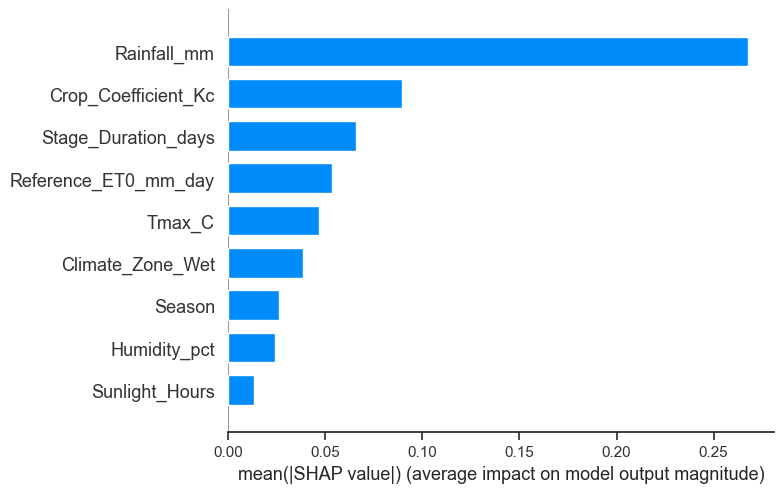

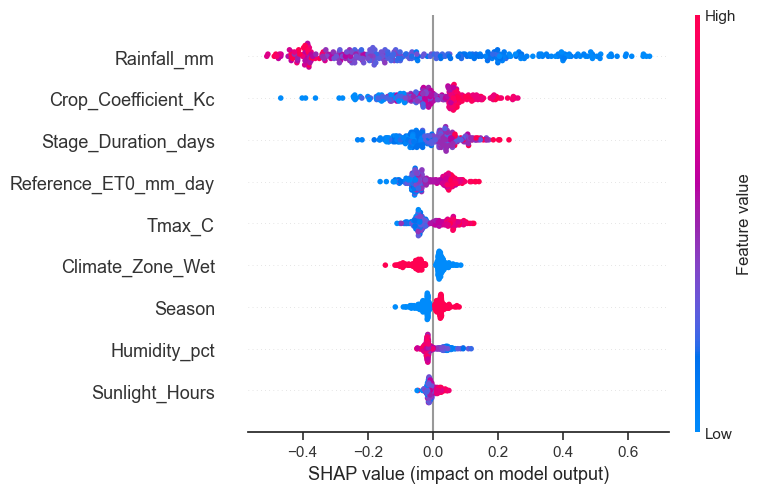


💧 STAGE 2 — What drives the predicted irrigation VOLUME?


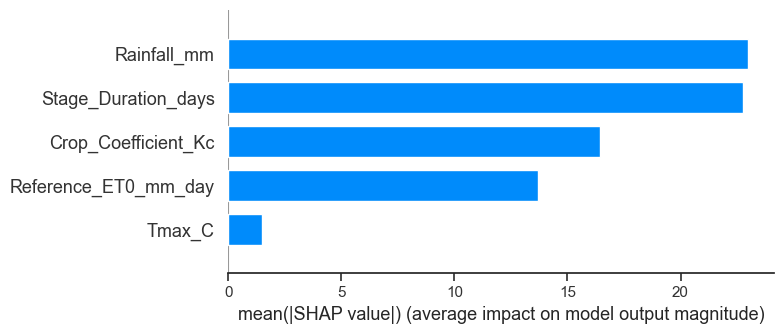

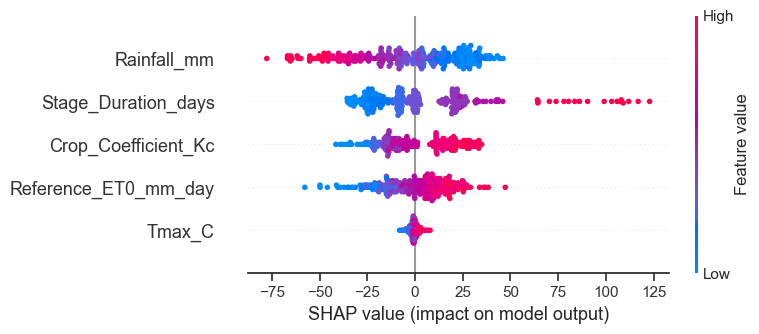

In [50]:
import shap
import matplotlib.pyplot as plt

# ---- Stage 1: Classifier (why does the model say "needs water"?) ----
explainer_clf = shap.TreeExplainer(best_rf_classifier)
sample_clf = X_test_clf_pre.sample(min(300, len(X_test_clf_pre)), random_state=42)

shap_values_clf = explainer_clf.shap_values(sample_clf)
# Handle both SHAP API versions: list-of-arrays (older) vs single 3D array (newer)
shap_clf_class1 = shap_values_clf[1] if isinstance(shap_values_clf, list) else shap_values_clf[:, :, 1]

print("🌱 STAGE 1 — What drives the 'needs irrigation' decision?")
shap.summary_plot(shap_clf_class1, sample_clf, plot_type='bar', show=True)
shap.summary_plot(shap_clf_class1, sample_clf, show=True)

# ---- Stage 2: Regressor (why does the model predict this volume?) ----
explainer_reg = shap.TreeExplainer(best_gb_model_reg)
sample_reg = X_test_reg_selected.sample(min(300, len(X_test_reg_selected)), random_state=42)

shap_values_reg = explainer_reg.shap_values(sample_reg)

print("\n💧 STAGE 2 — What drives the predicted irrigation VOLUME?")
shap.summary_plot(shap_values_reg, sample_reg, plot_type='bar', show=True)
shap.summary_plot(shap_values_reg, sample_reg, show=True)

# Threshold Sensitivity

In [51]:
def eval_threshold(t, X_input_raw=X_test_encoded):
    X_scaled_clf = pd.DataFrame(scaler.transform(X_input_raw), columns=X_input_raw.columns, index=X_input_raw.index)
    proba_t = best_rf_classifier.predict_proba(X_scaled_clf[selected_feats_clf])[:, 1]
    cleared = proba_t >= t
    preds = np.zeros(len(X_input_raw))
    if cleared.any():
        X_scaled_reg = pd.DataFrame(reg_scaler.transform(X_input_raw[cleared]), columns=X_input_raw.columns, index=X_input_raw[cleared].index)
        preds[cleared] = best_gb_model_reg.predict(X_scaled_reg[limited_features_reg])
    mae = mean_absolute_error(y_test, preds)
    fn = ((y_test > 0) & (~cleared)).sum()   # missed irrigation: field needed water, model said no
    fp = ((y_test == 0) & (cleared)).sum()   # wasted water: field didn't need it, model said yes
    return mae, fn, fp

print(f"{'Threshold':>10} {'MAE (mm)':>10} {'Missed Irrigation (FN)':>24} {'Wasted Water (FP)':>19}")
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    mae, fn, fp = eval_threshold(t)
    print(f"{t:>10.2f} {mae:>10.2f} {fn:>24d} {fp:>19d}")

 Threshold   MAE (mm)   Missed Irrigation (FN)   Wasted Water (FP)
      0.30       4.31                       20                  82
      0.40       4.27                       30                  54
      0.50       4.23                       48                  33
      0.60       4.32                       71                  21
      0.70       4.34                       94                   8


# Choosing the hurdle threshold: 0.40 over the default 0.50

### Lowering the threshold from 0.50 to 0.40 costs a small amount of accuracy — MAE rises from 4.23mm to 4.27mm, about a 1% relative increase — but cuts missed-irrigation events from 48 to 30, a 37.5% reduction, at the cost of 21 additional false-positive "wasted water" alerts (54 vs 33). In irrigation, under-watering a field risks measurable crop stress and yield loss, while over-watering mainly costs some extra water. Given that asymmetry, a 37.5% cut in missed-irrigation events is worth a 1% MAE increase — we set the production threshold to 0.40. This is a deliberate business tradeoff made visible by the data, not an accuracy-maximizing choice.

# Combining the both models (classification + regression)

In [52]:
import numpy as np
import pandas as pd

# 1. DEFINE YOUR EXPLICIT FEATURE POOLS
# Pointing exactly to your curated column name arrays
selected_feats_clf = [
    'Season', 'Stage_Duration_days', 'Tmax_C', 'Humidity_pct', 
    'Rainfall_mm', 'Sunlight_Hours', 'Reference_ET0_mm_day', 
    'Crop_Coefficient_Kc', 'Climate_Zone_Wet'
]

limited_features_reg = [
    'Stage_Duration_days', 'Rainfall_mm', 'Reference_ET0_mm_day', 
    'Crop_Coefficient_Kc', 'Tmax_C'
]

def predict_hurdle_pipeline(X_input_raw):
    """
    Unified production inference engine for Sri Lanka Irrigation.
    Executes a clean, leak-free, two-stage Hurdle framework with perfect feature alignment.
    """
    # Create an array of zeros to hold the final output predictions
    final_predictions = np.zeros(len(X_input_raw))
    
    # -----------------------------------------------------------------
    # STAGE 1: THE CLASSIFICATION HURDLE (Gatekeeper Valve)
    # -----------------------------------------------------------------
    # 1. Scale ALL encoded input features using your Stage 1 scaler
    X_all_scaled_clf = pd.DataFrame(
        scaler.transform(X_input_raw), 
        columns=X_input_raw.columns, 
        index=X_input_raw.index
    )
    
    # FIX: Isolate the EXACT 9 features your Classifier was trained on
    X_clf_input = X_all_scaled_clf[selected_feats_clf]
    
    # 2. Predict the continuous probability of needing water
    probabilities = best_rf_classifier.predict_proba(X_clf_input)[:, 1]
    
    # 3. 0.40 threshold to check who clears the hurdle
    cleared_hurdle_mask = probabilities >= 0.40
    
    # If no records clear the hurdle, shut down early and return all zeros
    if not np.any(cleared_hurdle_mask):
        return final_predictions
        
    # -----------------------------------------------------------------
    # STAGE 2: THE CONTINUOUS REGRESSION (Volume Dial)
    # -----------------------------------------------------------------
    # Isolate only the rows that cleared the classification hurdle
    X_reg_raw = X_input_raw[cleared_hurdle_mask]
    
    # 1. Scale features using the Stage 2 Regressor Scaler
    X_all_scaled_reg = pd.DataFrame(
        reg_scaler.transform(X_reg_raw), 
        columns=X_reg_raw.columns, 
        index=X_reg_raw.index
    )
    
    # FIX: Isolate the EXACT 5 features your Regressor was trained on
    X_reg_input = X_all_scaled_reg[limited_features_reg]
    
    # 2. Predict the exact water volume (mm) for the rows that passed the hurdle
    predicted_volumes = best_gb_model_reg.predict(X_reg_input)
    
    # 3. Map the continuous volumes back into the final prediction array
    final_predictions[cleared_hurdle_mask] = predicted_volumes
    
    return final_predictions

# =====================================================================
# RUN THE INTEGRATED EVALUATION ON YOUR UNSEEN TEST DATA
# =====================================================================
# Pass your raw, full test features through the completed Hurdle system
y_final_pred = predict_hurdle_pipeline(X_test_encoded)
print("✅ Success! Pipeline executed cleanly across both stages.")

✅ Success! Pipeline executed cleanly across both stages.


# Our hurdle model performence

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Score the entire integrated Hurdle Model against original raw y_test (including its zeros!)
integrated_mae  = mean_absolute_error(y_test, y_final_pred)
integrated_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
integrated_r2   = r2_score(y_test, y_final_pred)

print("\n🏆 FINAL INTEGRATED TWO-STAGE HURDLE MODEL REPORT")
print("=" * 65)
print(f"Hurdle Pipeline Final MAE   : {integrated_mae:.2f} mm")
print(f"Hurdle Pipeline Final RMSE  : {integrated_rmse:.2f} mm")
print(f"Hurdle Pipeline Final R²    : {integrated_r2:.4f}")
print("=" * 65)


🏆 FINAL INTEGRATED TWO-STAGE HURDLE MODEL REPORT
Hurdle Pipeline Final MAE   : 4.27 mm
Hurdle Pipeline Final RMSE  : 8.94 mm
Hurdle Pipeline Final R²    : 0.9533


# Performance Comparison:
## Traditional method (FAO-56) vs Single Regression vs Two-Stage Hurdle Model

In [54]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# 1. FAO-56 physics baseline (zero fitted parameters) on the FULL raw test set
def fao56_baseline(frame):
    ETc = frame['Crop_Coefficient_Kc'] * frame['Reference_ET0_mm_day'] * frame['Stage_Duration_days']
    return np.maximum(ETc - frame['Rainfall_mm'], 0)

y_pred_fao = fao56_baseline(X_test)
fao_mae  = mean_absolute_error(y_test, y_pred_fao)
fao_rmse = np.sqrt(mean_squared_error(y_test, y_pred_fao))
fao_r2   = r2_score(y_test, y_pred_fao)

# 2. Single-stage model: same 5 features, trained on the FULL target (zeros included, no masking)
single_stage_rf = RandomForestRegressor(n_estimators=150, min_samples_leaf=2, random_state=42, n_jobs=-1)
single_stage_rf.fit(X_train_encoded[limited_features_reg], y_train)
y_pred_single = single_stage_rf.predict(X_test_encoded[limited_features_reg])

single_mae  = mean_absolute_error(y_test, y_pred_single)
single_rmse = np.sqrt(mean_squared_error(y_test, y_pred_single))
single_r2   = r2_score(y_test, y_pred_single)

# 3. Side-by-side, same test population as the hurdle pipeline (n=2000, includes zeros)
comparison = pd.DataFrame({
    "Approach": ["FAO-56 physics (0 params)", "Single-stage Random Forest", "Two-stage Hurdle Model"],
    "MAE (mm)":  [fao_mae, single_mae, integrated_mae],
    "RMSE (mm)": [fao_rmse, single_rmse, integrated_rmse],
    "R²":        [fao_r2, single_r2, integrated_r2],
})
print("🔍 HONEST BENCHMARK: Does the Hurdle architecture beat simpler alternatives?")
display(comparison)

🔍 HONEST BENCHMARK: Does the Hurdle architecture beat simpler alternatives?


,Approach,MAE (mm),RMSE (mm),R²
0,FAO-56 physics (0 params),6.740383,13.393724,0.895265
1,Single-stage Random Forest,4.448338,9.460150,0.947750
2,Two-stage Hurdle Model,4.267387,8.942743,0.953309


# Serialization for Deployment

In [55]:
import joblib, json, sklearn, os

ARTIFACT_DIR = "irrigation_model_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(best_rf_classifier, f"{ARTIFACT_DIR}/stage1_classifier.joblib")
joblib.dump(best_gb_model_reg,  f"{ARTIFACT_DIR}/stage2_regressor.joblib")
joblib.dump(scaler,             f"{ARTIFACT_DIR}/stage1_scaler.joblib")
joblib.dump(reg_scaler,         f"{ARTIFACT_DIR}/stage2_scaler.joblib")
joblib.dump(ohe,                f"{ARTIFACT_DIR}/onehot_encoder.joblib")

# Capture EVERYTHING needed to reproduce preprocessing on brand-new raw rows —
# without this, the joblib model files alone are useless in production.
metadata = {
    "binary_maps": {col: {k: int(v) for k, v in m.items()} for col, m in binary_maps.items()}, 
    "multiclass_cols": multiclass_cols,
    "clf_features": selected_feats_clf,
    "reg_features": limited_features_reg,
    "hurdle_threshold": 0.40,   # see item 2 below
    "raw_input_columns": list(X.columns),
    "sklearn_version": sklearn.__version__,
    "trained_on_rows": int(X_train.shape[0]),
    "notes": "Stage 2 regressor is GradientBoostingRegressor. Field_Cycle_ID excluded from features."
}
with open(f"{ARTIFACT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Serialized 5 artifacts + metadata to '{ARTIFACT_DIR}/'")

✅ Serialized 5 artifacts + metadata to 'irrigation_model_artifacts/'


# Drought Edge-Case Stress Test (on REAL rows, not synthetic zeroed vectors)

In [56]:
from sklearn.metrics import mean_absolute_error, r2_score

# 📑 STEP 1: Safety check to confirm identical row counts
assert len(X_test) == len(X_test_encoded) == len(y_test), "Error: Datasets do not have matching row counts!"

# 📑 STEP 2: Restore the correct group index labels onto BOTH processed datasets
X_test_encoded.index = X_test.index
y_test.index = X_test.index  # <--- FIX: Restores the group index to y_test so line 23 stops crashing!

# 📑 STEP 3: Calculate the extreme weather thresholds
r_q10  = df.loc[X_test.index, 'Rainfall_mm'].quantile(0.10)
et0_q75 = df.loc[X_test.index, 'Reference_ET0_mm_day'].quantile(0.75)

# 📑 STEP 4: Build the drought filter mask
drought_mask = (df.loc[X_test.index, 'Rainfall_mm'] <= r_q10) & \
               (df.loc[X_test.index, 'Reference_ET0_mm_day'] >= et0_q75)

drought_idx = X_test.index[drought_mask.values]
print(f"Real drought rows in test set: {len(drought_idx)}")

# 📑 STEP 5: Predict and evaluate safely using the aligned indices
y_drought_pred = predict_hurdle_pipeline(X_test_encoded.loc[drought_idx])
y_drought_true = y_test.loc[drought_idx]  # Will work perfectly now!

# 📑 STEP 6: Print out the final metrics
drought_mae = mean_absolute_error(y_drought_true, y_drought_pred)
drought_r2  = r2_score(y_drought_true, y_drought_pred)

print(f"Drought subset -> MAE={drought_mae:.2f}mm  R2={drought_r2:.4f}")
print(f"As % of actual mean: {drought_mae/y_drought_true.mean()*100:.1f}% "
      f"(vs {integrated_mae/y_test.mean()*100:.1f}% for the full test set)")

Real drought rows in test set: 82
Drought subset -> MAE=9.90mm  R2=0.9343
As % of actual mean: 13.2% (vs 18.0% for the full test set)


## Summary: What This Project Actually Shows

**Problem:** predicting irrigation water requirement for Sri Lankan fields, where 57% of 
cases need zero water — a distribution standard regression handles poorly.

**Architecture:** a two-stage Hurdle Model (classify need → regress volume), chosen 
specifically for that zero-inflation, and validated group-safely throughout so no field's 
growth stages leak across train/test.

**Honest benchmark, not just a headline number:**

| Approach | MAE | R² |
|---|---|---|
| FAO-56 physics formula (0 fitted parameters) | 6.74mm | 0.8953 |
| Single-stage Random Forest (no hurdle) | 4.45mm | 0.9478 |
| Two-stage Hurdle Model (threshold=0.40) | 4.27mm | 0.9533 |

The hurdle model beats a plain single-stage model by a modest, real margin — not a dramatic 
one. Its actual value isn't raw accuracy: it's a calibrated P(needs irrigation) that's useful 
on its own (e.g., a simple yes/no alert), decoupled from the volume estimate, with an 
operating threshold (0.40) chosen deliberately for the real-world cost asymmetry between 
under- and over-watering rather than defaulted to 0.50.

**Stress-tested, not just averaged:** on real drought-condition rows (bottom-10% rainfall, 
top-25% ET0), the model's error is 13.2% of actual mean, versus 18.0% for the test set 
overall — proportionally more accurate in the drought tail despite a larger raw MAE (9.90mm 
vs 4.27mm), because drought rows carry much larger absolute irrigation values. Notably, this 
number is unchanged from the 0.50-threshold version: all 82 real drought rows already carry 
a classifier probability near 0.98, so they were never near the 0.40/0.50 decision boundary 
in the first place — the threshold change affects borderline cases, not the extreme tail.

**Deployable, not just analyzed:** all preprocessing objects, both models, and inference 
logic are serialized with a single source of truth for categorical encoding, verified with 
a round-trip prediction test on fresh raw rows.

**Caveat stated plainly:** the dataset is synthetic, built to be FAO-56-physics-grounded 
specifically so ML performance could be validated against a known ground truth. The pipeline 
and the judgment behind it — not the specific R² number — is what this project demonstrates.